In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Set the visual style for VS Code
sns.set_theme(style = "whitegrid")

#Create a synthetic dataset for the lesson
np.random.seed(42)
data = pd.DataFrame({
    'Group': np.repeat(['Control', 'Treatment'], 50),
    'Score': np.concatenate([np.random.normal(100, 15, 50), np.random.normal(110, 15, 50)]),
    'Hours Studied': np.random.uniform(1, 10, 100),
    'Category': np.random.choice(['A', 'B', 'C'], 100)
})

In [60]:
# Dataset Overview
data

,Group,Score,Hours Studied,Category
0,Control,107.450712,4.756699,B
1,Control,97.926035,2.998970,A
2,Control,109.715328,2.078788,B
3,Control,122.845448,4.038537,A
4,Control,96.487699,9.486187,C
...,...,...,...,...
95,Treatment,88.047276,3.195907,C
96,Treatment,114.441804,9.757095,A
97,Treatment,113.915829,4.537880,A
98,Treatment,110.076702,9.028419,A


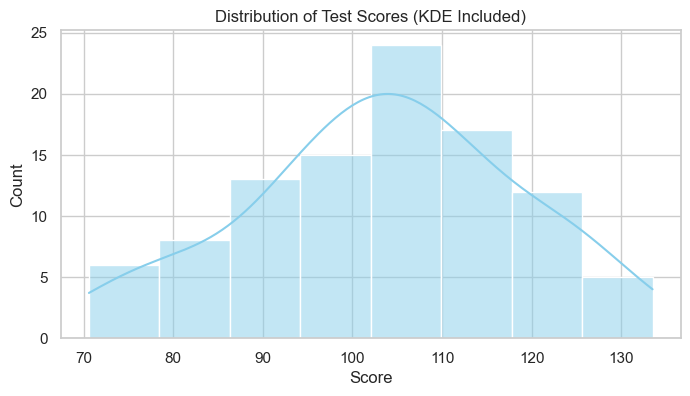

In [61]:
# Histogram

plt.figure(figsize=(8, 4))
sns.histplot(
    data,
    x = 'Score',
    kde = True,
    color = 'skyblue'
)
plt.title('Distribution of Test Scores (KDE Included)')
plt.show()

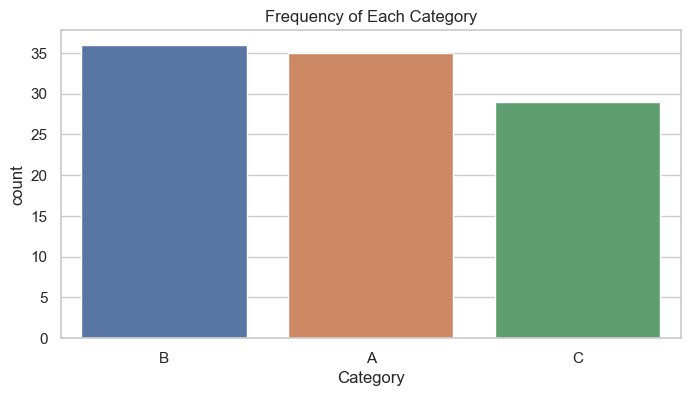

In [64]:
# Bar Chart

plt.figure(figsize=(8, 4))
sns.countplot(
    data,
    x = 'Category',
    hue = 'Category'
)
plt.title('Frequency of Each Category'),
plt.show()

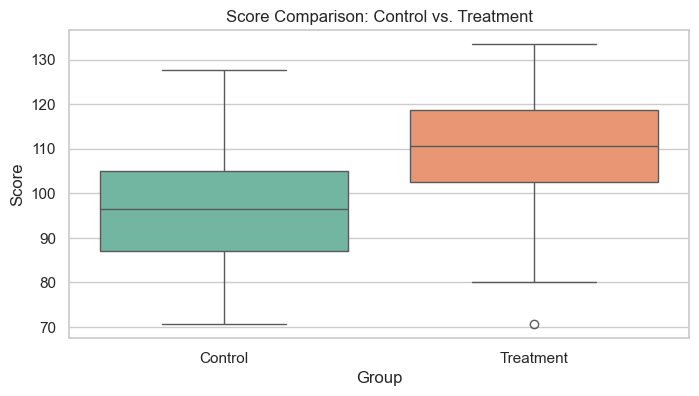

In [3]:
plt.figure(figsize=(8,4))
sns.boxplot(
    data,
    x='Group',
    y = 'Score',
    hue = 'Group',
    palette='Set2'
)
plt.title('Score Comparison: Control vs. Treatment')
plt.show()

In [17]:
# Five-Number Summary

# Calculate the five-number summary for each group
five_num = data.groupby('Group').describe()[['Score', 'Hours Studied']].loc[:,(slice(None), ['min','25%','50%','75%','max'])]

print("Five-Number Summary by Group:")
display(five_num)

Five-Number Summary by Group:


Score                                                  \
                 min         25%         50%         75%         max   
Group                                                                  
Control    70.604948   87.085313   96.487823  105.044133  127.784173   
Treatment  70.703823  102.558330  110.691204  118.806111  133.469655   

          Hours Studied                                          
                    min       25%       50%       75%       max  
Group                                                            
Control        1.149290  3.143068  4.618659  6.988554  9.870854  
Treatment      1.045554  3.227299  6.286319  7.672217  9.757095

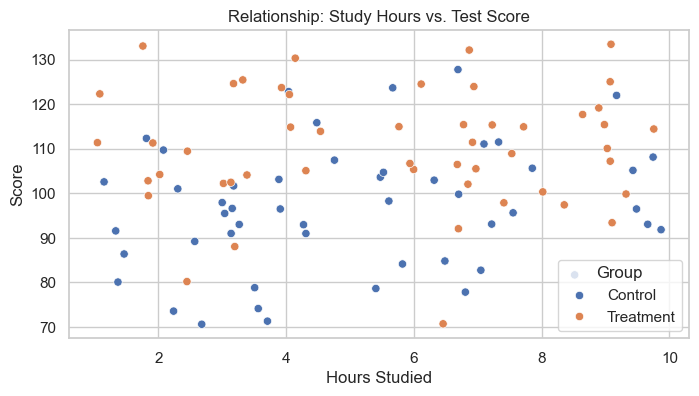

In [ ]:
# Scatterplot

plt.figure(figsize=(8,4))
sns.scatterplot(
    data,
    x= 'Hours Studied',
    y= 'Score',
    hue= 'Group'
)
plt.title("Relationship: Study Hours vs. Test Score")
plt.show()

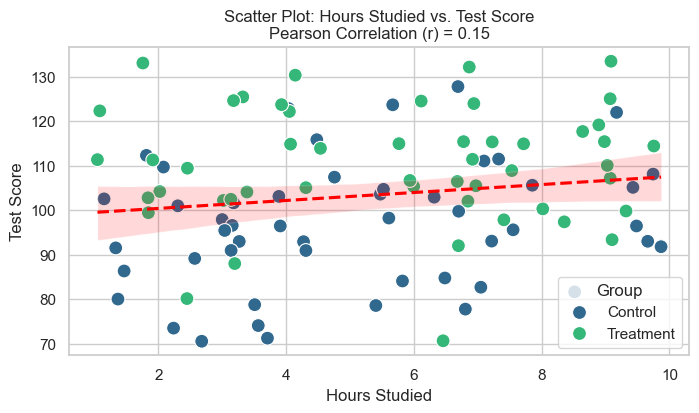

In [85]:
# Correlation

corr_value = data['Hours Studied'].corr(data['Score'])

plt.figure(figsize=(8,4))
sns.scatterplot(
    data,
    x = 'Hours Studied',
    y = 'Score',
    hue = 'Group',
    palette = 'viridis',
    s = 100
)

sns.regplot(
    data,
    x = 'Hours Studied',
    y = 'Score',
    scatter = False,
    color = 'red',
    line_kws = {"ls":"--"}
)

plt.title(f'Scatter Plot: Hours Studied vs. Test Score\nPearson Correlation (r) = {corr_value:.2f}')
plt.xlabel('Hours Studied')
plt.ylabel('Test Score')

plt.show()